In [1]:
import cv2
import matplotlib.pyplot as plt
import os
import random
import numpy as np
import pandas as pd
from glob import glob
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision.models import densenet121
import torchvision.models as models
from torch import Tensor

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.model_selection import StratifiedKFold, train_test_split


class CFG:
    DATASET_PATH = "/kaggle/input/prdb-rice/Original_Images"
    SEARCH_ROOTS = [DATASET_PATH, "/kaggle/input"]
    IMG_EXTS = (".jpg")
    IMG_SIZE = 224
    SEED = 42
    NUM_WORKERS = 2
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    SSL_BATCH = 64
    SSL_EPOCHS = 150
    SSL_LR = 3e-4
    SSL_WEIGHT_DECAY = 1e-4
    TEMP = 0.2
    PROJ_DIM = 128
    LP_BATCH = 32
    LP_EPOCHS = 30
    LP_LR = 1e-3
    USE_FOCAL = False
    VAL_SIZE = 0.2
    TEST_SIZE = 0.1
    ROI_CROP_PROB = 0.0
    INTENSITY_GAIN_RANGE = (0.8, 1.2)
    INTENSITY_BIAS_RANGE = (-15, 15)
    BG_ERASE_PROB = 0.4
    BG_ERASE_RATE = 0.1
    OUT_DIR = "/kaggle/working/prdb_ssl"
    
    SSL_CKPT_INCEPTION = "ssl_backbone_inception.pth"
    LP_CKPT_INCEPTION = "lp_classifier_inception.pth"
    

os.makedirs(CFG.OUT_DIR, exist_ok=True)

def set_seed(seed=CFG.SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()


In [2]:
# 1. Class Map for PRDB
CLASS_MAP = {
    "Aush": 0,
    "Beroi": 1,
    "BR-28": 2,
    "BR-29": 3,
    "Chinigura": 4,
    "Ghee Bhog": 5,
    "Katari Najir": 6,
    "Katari Siddho": 7,
    "Miniket": 8,
    "Swarna":9
}

PRDB_ROOT = "/kaggle/input/prdb-rice/Original_Images"

assert os.path.exists(PRDB_ROOT), "ERROR: PRDB dataset path does NOT exist!"
print("[INFO] Using PRDB root:", PRDB_ROOT)


# 2. Build Image Index
def build_index(root=PRDB_ROOT):
    rows = []
    for cls, lbl in CLASS_MAP.items():
        cls_folder = os.path.join(root, cls)
        for img_path in glob(os.path.join(cls_folder, "*")):
            if not img_path.lower().endswith(CFG.IMG_EXTS):
                continue
            rows.append({"image": img_path, "label": lbl, "cls": cls})
    df = pd.DataFrame(rows)
    print("Counts per class:\n", df["cls"].value_counts())
    return df

df_all = build_index(PRDB_ROOT)


[INFO] Using PRDB root: /kaggle/input/prdb-rice/Original_Images
Counts per class:
 cls
Aush             200
Beroi            200
BR-28            200
BR-29            200
Chinigura        200
Ghee Bhog        200
Katari Najir     200
Katari Siddho    200
Miniket          200
Swarna           200
Name: count, dtype: int64


In [3]:
import shutil
import os
from sklearn.model_selection import train_test_split

# Base directory for split data
base_split_dir = os.path.join(CFG.OUT_DIR, "split_data")
train_dir = os.path.join(base_split_dir, "train")
val_dir = os.path.join(base_split_dir, "val")
test_dir = os.path.join(base_split_dir, "test")

# Create base split directories
os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

print("Splitting dataset into train (80%), val (10% of training), test (20%) for each class...")

for class_name, class_label in CLASS_MAP.items():
    # Filter images of current class
    class_df = df_all[df_all['cls'] == class_name]
    images_full_paths = class_df['image'].tolist()

    if not images_full_paths:
        print(f"[WARN] No images found for class {class_name}. Skipping.")
        continue

    # First split: train 80%, test 20%
    train_imgs, test_imgs = train_test_split(
        images_full_paths, test_size=0.20, random_state=CFG.SEED
    )

    # Second split: allocate 10% of training as validation
    val_size = 0.10  # 10% of training
    train_imgs, val_imgs = train_test_split(
        train_imgs, test_size=val_size, random_state=CFG.SEED
    )

    # Create class folders
    for d in [train_dir, val_dir, test_dir]:
        os.makedirs(os.path.join(d, class_name), exist_ok=True)

    # Copy files
    for img_path in train_imgs:
        shutil.copy(img_path, os.path.join(train_dir, class_name, os.path.basename(img_path)))
    for img_path in val_imgs:
        shutil.copy(img_path, os.path.join(val_dir, class_name, os.path.basename(img_path)))
    for img_path in test_imgs:
        shutil.copy(img_path, os.path.join(test_dir, class_name, os.path.basename(img_path)))

    print(f"{class_name}: Train={len(train_imgs)}, Val={len(val_imgs)}, Test={len(test_imgs)}")



Splitting dataset into train (80%), val (10% of training), test (20%) for each class...
Aush: Train=144, Val=16, Test=40
Beroi: Train=144, Val=16, Test=40
BR-28: Train=144, Val=16, Test=40
BR-29: Train=144, Val=16, Test=40
Chinigura: Train=144, Val=16, Test=40
Ghee Bhog: Train=144, Val=16, Test=40
Katari Najir: Train=144, Val=16, Test=40
Katari Siddho: Train=144, Val=16, Test=40
Miniket: Train=144, Val=16, Test=40
Swarna: Train=144, Val=16, Test=40


In [4]:
!pip install lightly


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 859.3/859.3 kB 16.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.6/165.6 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 100.0 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 67.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 35.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 14.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Starting Training
epoch: 00, loss: 4.15441
epoch: 01, loss: 4.10858
epoch: 02, loss: 3.99016
epoch: 03, loss: 3.86312
epoch: 04, loss: 3.73755
epoch: 05, loss: 3.67240
epoch: 06, loss: 3.62446
epoch: 07, loss: 3.52217
epoch: 08, loss: 3.49496
epoch: 09, loss: 3.46630
epoch: 10, loss: 3.40597
epoch: 11, loss: 3.38699
epoch: 12, loss: 3.37987
epoch: 13, loss: 3.32256
epoch: 14, loss: 3.32890
epoch: 15, loss: 3.29492
epoch: 16, loss: 3.30699
epoch: 17, loss: 3.25744
epoch: 18, loss: 3.23962
epoch: 19, loss: 3.24899
epoch: 20, loss: 3.20950
epoch: 21, loss: 3.26459
epoch: 22, loss: 3.19121
epoch: 23, loss: 3.19177
epoch: 24, loss: 3.19061
epoch: 25, loss: 3.14358
epoch: 26, loss: 3.13661
epoch: 27, loss: 3.14692
epoch: 28, loss: 3.12556
epoch: 29, loss: 3.10582
epoch: 30, loss: 3.10719
epoch: 31, loss: 3.10660
epoch: 32, loss: 3.07449
epoch: 33, loss: 3.06293
epoch: 34, loss: 3.05439
epoch: 35, loss: 3.09064
epoch: 36, loss: 3.08629
epoch: 37, loss: 3.05273
epoch: 38, loss: 3.04115
epoch: 

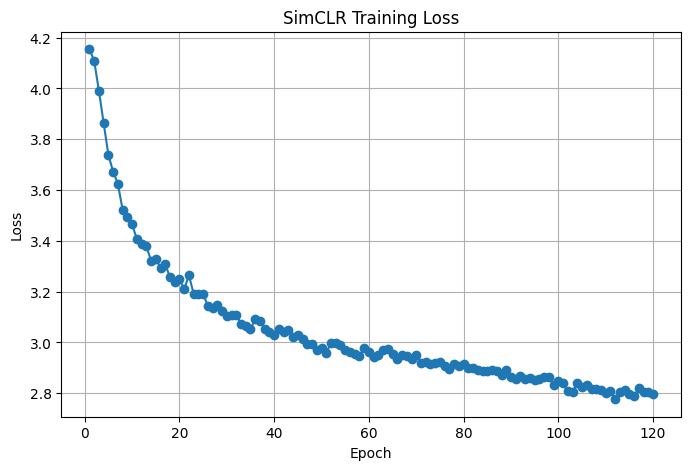

In [2]:
import torch
import torchvision
from torch import nn

from lightly.loss import NTXentLoss
from lightly.models.modules import SimCLRProjectionHead
from lightly.transforms.simclr_transform import SimCLRTransform
from lightly.data import LightlyDataset   # <-- added


class SimCLR(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone
        # DenseNet-121 output features = 1024
        self.projection_head = SimCLRProjectionHead(1024, 1024, 128)

    def forward(self, x):
        x = self.backbone(x).flatten(start_dim=1)
        z = self.projection_head(x)
        return z


densenet = torchvision.models.densenet121(weights=None)

backbone = nn.Sequential(
    densenet.features,
    nn.AdaptiveAvgPool2d((1, 1))  # global avg pool
)

model = SimCLR(backbone)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)


transform = SimCLRTransform(input_size=224, gaussian_blur=0.0)

dataset = LightlyDataset(
    input_dir="/kaggle/working/prdb_ssl/split_data/train",
    transform=transform
)

dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=32,
    shuffle=True,
    drop_last=True,
    num_workers=8,
)


criterion = NTXentLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.06)
all_losses = []

print("Starting Training")
for epoch in range(120):
    total_loss = 0
    for batch in dataloader:
        (x0, x1), _, _ = batch   # labels exist but ignored
        x0 = x0.to(device)
        x1 = x1.to(device)

        z0 = model(x0)
        z1 = model(x1)

        loss = criterion(z0, z1)
        total_loss += loss.detach()

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    avg_loss = total_loss / len(dataloader)
    all_losses.append(avg_loss.cpu().item()) 
    print(f"epoch: {epoch:>02}, loss: {avg_loss:.5f}")


import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, len(all_losses)+1), all_losses, marker='o')
plt.title("SimCLR Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


****Linear Probe****

Epoch 1/80 Train Acc: 54.31%
Epoch 2/80 Train Acc: 73.06%
Epoch 3/80 Train Acc: 76.74%
Epoch 4/80 Train Acc: 77.71%
Epoch 5/80 Train Acc: 79.03%
Epoch 6/80 Train Acc: 79.38%
Epoch 7/80 Train Acc: 81.74%
Epoch 8/80 Train Acc: 79.93%
Epoch 9/80 Train Acc: 80.97%
Epoch 10/80 Train Acc: 81.60%
Epoch 11/80 Train Acc: 81.81%
Epoch 12/80 Train Acc: 82.71%
Epoch 13/80 Train Acc: 82.64%
Epoch 14/80 Train Acc: 82.92%
Epoch 15/80 Train Acc: 82.92%
Epoch 16/80 Train Acc: 83.96%
Epoch 17/80 Train Acc: 84.31%
Epoch 18/80 Train Acc: 84.93%
Epoch 19/80 Train Acc: 84.24%
Epoch 20/80 Train Acc: 85.49%
Epoch 21/80 Train Acc: 84.31%
Epoch 22/80 Train Acc: 84.65%
Epoch 23/80 Train Acc: 85.49%
Epoch 24/80 Train Acc: 85.49%
Epoch 25/80 Train Acc: 85.35%
Epoch 26/80 Train Acc: 85.69%
Epoch 27/80 Train Acc: 85.21%
Epoch 28/80 Train Acc: 86.32%
Epoch 29/80 Train Acc: 86.67%
Epoch 30/80 Train Acc: 86.60%
Epoch 31/80 Train Acc: 87.08%
Epoch 32/80 Train Acc: 86.39%
Epoch 33/80 Train Acc: 86.39%
Epoch 34/80 Train A

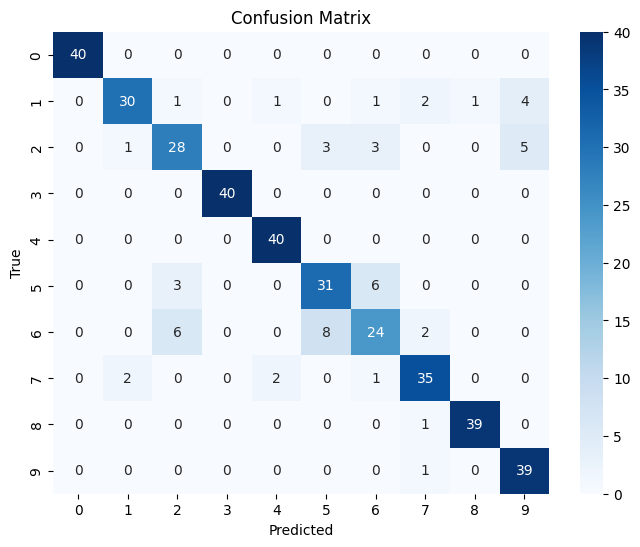

In [10]:
import torch
from torch import nn, optim
from torchvision import datasets, transforms
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

device = "cuda" if torch.cuda.is_available() else "cpu"

# Freeze backbone
for param in backbone.parameters():
    param.requires_grad = False

# Linear probe
class LinearProbe(nn.Module):
    def __init__(self, backbone, feature_dim=1024, num_classes=10):
        super().__init__()
        self.backbone = backbone
        self.classifier = nn.Linear(feature_dim, num_classes)

    def forward(self, x):
        with torch.no_grad():
            features = self.backbone(x).flatten(1)
        return self.classifier(features)

model = LinearProbe(backbone, feature_dim=1024, num_classes=10).to(device)

# Data loaders
transform = transforms.Compose([transforms.Resize((224,224)), transforms.ToTensor()])

train_loader = torch.utils.data.DataLoader(
    datasets.ImageFolder("/kaggle/working/prdb_ssl/split_data/train", transform=transform),
    batch_size=32, shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    datasets.ImageFolder("/kaggle/working/prdb_ssl/split_data/test", transform=transform),
    batch_size=32, shuffle=False
)

# Training
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.classifier.parameters(), lr=0.01, momentum=0.9)
epochs = 80

for epoch in range(epochs):
    model.train()
    correct = total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        _, preds = outputs.max(1)
        total += labels.size(0)
        correct += preds.eq(labels).sum().item()
    print(f"Epoch {epoch+1}/{epochs} Train Acc: {100*correct/total:.2f}%")

# Evaluation
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    correct = total = 0
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = outputs.max(1)
        total += labels.size(0)
        correct += preds.eq(labels).sum().item()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(f"\nFINAL TEST ACCURACY: {100*correct/total:.2f}%")
print("\nClassification Report:\n", classification_report(all_labels, all_preds, digits=4))

# Confusion matrix as image
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


****MLP****

Epoch 1/80 Train Acc: 42.36%
Epoch 2/80 Train Acc: 64.38%
Epoch 3/80 Train Acc: 68.40%
Epoch 4/80 Train Acc: 74.93%
Epoch 5/80 Train Acc: 74.72%
Epoch 6/80 Train Acc: 75.56%
Epoch 7/80 Train Acc: 76.60%
Epoch 8/80 Train Acc: 77.29%
Epoch 9/80 Train Acc: 78.54%
Epoch 10/80 Train Acc: 77.57%
Epoch 11/80 Train Acc: 78.19%
Epoch 12/80 Train Acc: 80.42%
Epoch 13/80 Train Acc: 81.53%
Epoch 14/80 Train Acc: 80.56%
Epoch 15/80 Train Acc: 81.39%
Epoch 16/80 Train Acc: 81.81%
Epoch 17/80 Train Acc: 81.18%
Epoch 18/80 Train Acc: 82.29%
Epoch 19/80 Train Acc: 82.78%
Epoch 20/80 Train Acc: 83.54%
Epoch 21/80 Train Acc: 83.54%
Epoch 22/80 Train Acc: 85.62%
Epoch 23/80 Train Acc: 84.38%
Epoch 24/80 Train Acc: 84.86%
Epoch 25/80 Train Acc: 82.92%
Epoch 26/80 Train Acc: 84.10%
Epoch 27/80 Train Acc: 83.61%
Epoch 28/80 Train Acc: 83.82%
Epoch 29/80 Train Acc: 83.68%
Epoch 30/80 Train Acc: 85.49%
Epoch 31/80 Train Acc: 84.58%
Epoch 32/80 Train Acc: 84.86%
Epoch 33/80 Train Acc: 86.46%
Epoch 34/80 Train A

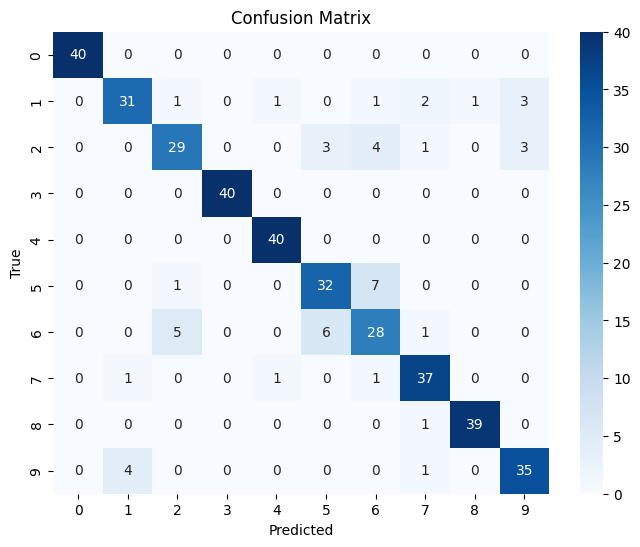

In [12]:
import torch
from torch import nn, optim
from torchvision import datasets, transforms
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

device = "cuda" if torch.cuda.is_available() else "cpu"

# Freeze backbone
for param in backbone.parameters():
    param.requires_grad = False

# MLP Probe 
class MLPProbe(nn.Module):
    def __init__(self, backbone, feature_dim=1024, hidden_dim=512, num_classes=10, dropout=0.5):
        super().__init__()
        self.backbone = backbone
        self.mlp = nn.Sequential(
            nn.Linear(feature_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        with torch.no_grad():  # freeze backbone
            features = self.backbone(x).flatten(1)
        return self.mlp(features)

model = MLPProbe(backbone, feature_dim=1024, hidden_dim=512, num_classes=10).to(device)

# Data 
transform = transforms.Compose([transforms.Resize((224,224)), transforms.ToTensor()])
train_loader = torch.utils.data.DataLoader(
    datasets.ImageFolder("/kaggle/working/prdb_ssl/split_data/train", transform=transform),
    batch_size=32, shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    datasets.ImageFolder("/kaggle/working/prdb_ssl/split_data/test", transform=transform),
    batch_size=32, shuffle=False
)

#Training 
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.mlp.parameters(), lr=0.01, momentum=0.9)
epochs = 80

for epoch in range(epochs):
    model.train()
    correct = total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        _, preds = outputs.max(1)
        total += labels.size(0)
        correct += preds.eq(labels).sum().item()
    print(f"Epoch {epoch+1}/{epochs} Train Acc: {100*correct/total:.2f}%")

#Evaluation 
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    correct = total = 0
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = outputs.max(1)
        total += labels.size(0)
        correct += preds.eq(labels).sum().item()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(f"\n FINAL TEST ACCURACY: {100*correct/total:.2f}%")
print("\nClassification Report:\n", classification_report(all_labels, all_preds, digits=4))

#Confusion Matrix as Image 
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


****SVM****


 SVM TEST ACCURACY: 86.50%

Classification Report:
               precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        40
           1     0.8571    0.7500    0.8000        40
           2     0.6977    0.7500    0.7229        40
           3     1.0000    1.0000    1.0000        40
           4     0.9302    1.0000    0.9639        40
           5     0.7895    0.7500    0.7692        40
           6     0.7368    0.7000    0.7179        40
           7     0.8250    0.8250    0.8250        40
           8     0.9750    0.9750    0.9750        40
           9     0.8372    0.9000    0.8675        40

    accuracy                         0.8650       400
   macro avg     0.8649    0.8650    0.8641       400
weighted avg     0.8649    0.8650    0.8641       400



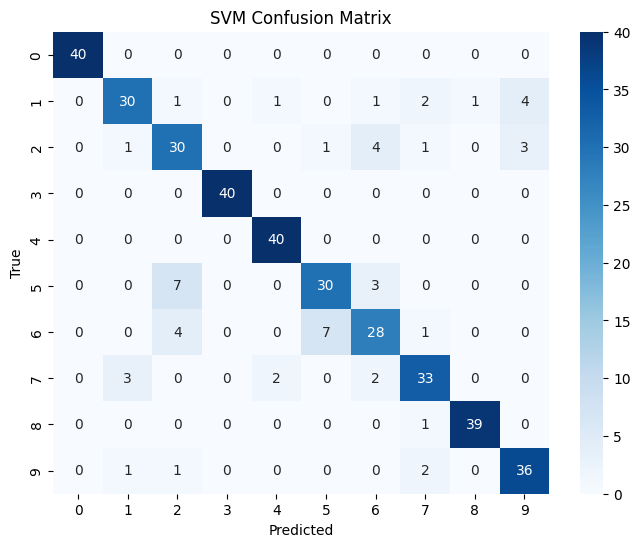

In [13]:
import torch
from torch import nn
from torchvision import datasets, transforms
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"

# ======= Feature Extraction 
# Freeze backbone
for param in backbone.parameters():
    param.requires_grad = False
backbone.eval()

def extract_features(dataloader):
    features_list, labels_list = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            features = backbone(images).flatten(1)  # flatten
            features_list.append(features.cpu().numpy())
            labels_list.append(labels.numpy())
    X = np.concatenate(features_list, axis=0)
    y = np.concatenate(labels_list, axis=0)
    return X, y

# Data
transform = transforms.Compose([transforms.Resize((224,224)), transforms.ToTensor()])
train_loader = torch.utils.data.DataLoader(
    datasets.ImageFolder("/kaggle/working/prdb_ssl/split_data/train", transform=transform),
    batch_size=32, shuffle=False
)
test_loader = torch.utils.data.DataLoader(
    datasets.ImageFolder("/kaggle/working/prdb_ssl/split_data/test", transform=transform),
    batch_size=32, shuffle=False
)

# Extract features
X_train, y_train = extract_features(train_loader)
X_test, y_test = extract_features(test_loader)

# ======= SVM Training 
svm_clf = SVC(kernel='linear', C=1.0)
svm_clf.fit(X_train, y_train)

# ======= Evaluation 
y_pred = svm_clf.predict(X_test)

print(f"\n SVM TEST ACCURACY: {100*np.mean(y_pred==y_test):.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))

# Confusion Matrix as image
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("SVM Confusion Matrix")
plt.show()


****Decision Tree****


 Decision Tree TEST ACCURACY: 72.00%

Classification Report:
               precision    recall  f1-score   support

           0     0.9750    0.9750    0.9750        40
           1     0.6000    0.6000    0.6000        40
           2     0.6053    0.5750    0.5897        40
           3     1.0000    1.0000    1.0000        40
           4     0.7955    0.8750    0.8333        40
           5     0.6316    0.6000    0.6154        40
           6     0.4000    0.4000    0.4000        40
           7     0.6098    0.6250    0.6173        40
           8     0.8974    0.8750    0.8861        40
           9     0.6750    0.6750    0.6750        40

    accuracy                         0.7200       400
   macro avg     0.7189    0.7200    0.7192       400
weighted avg     0.7189    0.7200    0.7192       400



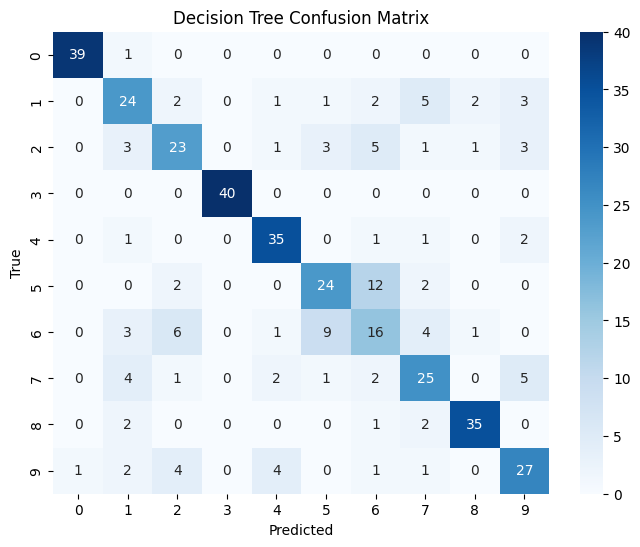

In [14]:
import torch
from torchvision import datasets, transforms
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"

# Freeze Backbone 
for param in backbone.parameters():
    param.requires_grad = False
backbone.eval()

# Feature Extraction 
def extract_features(dataloader):
    features_list, labels_list = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            features = backbone(images).flatten(1)  # flatten to (batch, features)
            features_list.append(features.cpu().numpy())
            labels_list.append(labels.numpy())
    X = np.concatenate(features_list, axis=0)
    y = np.concatenate(labels_list, axis=0)
    return X, y

# Data Loaders 
transform = transforms.Compose([transforms.Resize((224,224)), transforms.ToTensor()])
train_loader = torch.utils.data.DataLoader(
    datasets.ImageFolder("/kaggle/working/prdb_ssl/split_data/train", transform=transform),
    batch_size=32, shuffle=False
)
test_loader = torch.utils.data.DataLoader(
    datasets.ImageFolder("/kaggle/working/prdb_ssl/split_data/test", transform=transform),
    batch_size=32, shuffle=False
)

# Extract features
X_train, y_train = extract_features(train_loader)
X_test, y_test = extract_features(test_loader)

# ======= Decision Tree ======= #
dt_clf = DecisionTreeClassifier(max_depth=15, random_state=42)
dt_clf.fit(X_train, y_train)

# ======= Evaluation ======= #
y_pred = dt_clf.predict(X_test)

print(f"\n Decision Tree TEST ACCURACY: {100*np.mean(y_pred==y_test):.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Decision Tree Confusion Matrix")
plt.show()
